In [1]:
import os
import joblib
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# =========================================================
# 0. 基础设置
# =========================================================

random_seed = 212
np.random.seed(random_seed)

data_path = r'D:\AI4polymer\cocrystal design\Data-0320\deltaML result\deltaML4DFT_rawMD_merged_data_0512.xlsx'

virtual_path = r'D:\AI4polymer\cocrystal design\Data-0320\deltaML result\deltaML4DFT_rawMD_merged_data.xlsx'

save_dir = r'D:\AI4polymer\cocrystal design\Data-0320\deltaML result\saved_PTT_PDT_models'
os.makedirs(save_dir, exist_ok=True)

output_path = r'D:\AI4polymer\cocrystal design\Data-0320\deltaML result\virtual_300_PTT_PDT_prediction.xlsx'


DFT_cols = [
    'es1_ev_high_pred',
    'fs1_high_pred',
    'et1_ev_high_pred',
    'delta_est_ev_high_pred',
    'min_abs_s1_tn_ev_high_pred',
    'd_index_ang_high_pred',
    't_index_ang_high_pred',
    'zpe_ha_pred',
    'gcorr_ha_pred',
    'alpha_iso_bohr3_pred',
    's_vib_cal_molk_pred',
    'svib_frac_pred',
    'hlg_kjmol_high_pred',
    'dipole_gs_debye_high_pred',
    'ci_index',
]

MD_cols = [
    'vdw_energy_kjmol',
    'total_energy_kjmol',
    'rg_center_norm',
    'rdf_first_peak_height',
    'hbond_dynamic',
    'hbond_static'
]

feature_cols = DFT_cols + MD_cols


# =========================================================
# 1. 读取训练数据
# =========================================================

data = pd.read_excel(data_path)

data_PTT = data.dropna(subset=['photothermal']).copy()
data_PTT.reset_index(drop=True, inplace=True)

data_PDT = data.dropna(subset=['photodynamic']).copy()
data_PDT.reset_index(drop=True, inplace=True)

# 这里保持你原来的逻辑：去掉所有含 NaN 的行
data_PTT = data_PTT.dropna().reset_index(drop=True)
data_PDT = data_PDT.dropna().reset_index(drop=True)


# =========================================================
# 2. 通用函数：准备数据
# =========================================================

def prepare_classification_data(df, target_raw_col, target_bin_col, feature_cols):
    """
    将 middle 合并到 weak，并将 strong/weak 编码为 1/0。
    """
    df = df.copy()

    df[target_bin_col] = df[target_raw_col].astype(str).replace({
        "middle": "weak"
    })

    existing_feature_cols = [col for col in feature_cols if col in df.columns]
    missing_cols = [col for col in feature_cols if col not in df.columns]

    print(f"\n===== {target_bin_col} 数据准备 =====")
    print("存在的特征列数:", len(existing_feature_cols))
    print("缺失的列:", missing_cols)

    X = df[existing_feature_cols].copy()

    non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
    if len(non_numeric_cols) > 0:
        print("以下非数值列将被移除:")
        print(non_numeric_cols)

    X = X.select_dtypes(include=[np.number]).copy()
    final_feature_cols = X.columns.tolist()

    y = df[target_bin_col].map({
        'strong': 1,
        'weak': 0
    })

    if y.isnull().any():
        bad_labels = df.loc[y.isnull(), target_bin_col].unique()
        raise ValueError(
            f"{target_bin_col} 中存在不是 strong/weak 的标签: {bad_labels}"
        )

    print("最终用于建模的特征数:", X.shape[1])
    print("最终特征列:")
    print(final_feature_cols)

    print("\n标签分布:")
    print(y.value_counts())

    return X, y, final_feature_cols


# =========================================================
# 3. 通用函数：训练并保存 10 折模型
# =========================================================

def train_and_save_cv_models(
    X,
    y,
    model_name,
    save_dir,
    n_splits=10,
    random_seed=random_seed
):
    """
    手动进行 StratifiedKFold。
    每一折训练一个模型，并保存为 joblib。
    同时保存该模型使用的特征列。
    """

    model_dir = os.path.join(save_dir, model_name)
    os.makedirs(model_dir, exist_ok=True)

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_seed
    )

    fold_metrics = []
    all_y_true = []
    all_y_pred = []
    all_y_proba = []

    feature_cols_used = X.columns.tolist()

    print(f"\n\n==============================")
    print(f"Training {model_name} models")
    print(f"==============================")

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        print(f"\n----- Fold {fold}/{n_splits} -----")

        X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
        y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

        if model_name == 'PTT':
            pipeline = Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('rf', RandomForestClassifier(class_weight='balanced',
                                        max_features=0.5, min_samples_leaf=2,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=212))
            ])

            

        elif model_name == 'PDT':
            pipeline = Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('rf', RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        max_features=0.5, min_samples_leaf=2,
                                        n_jobs=-1, random_state=212))
            ])


        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        pre = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba)
        else:
            auc = np.nan

        print(f"Accuracy : {acc:.4f}")
        print(f"Precision: {pre:.4f}")
        print(f"Recall   : {rec:.4f}")
        print(f"F1-score : {f1:.4f}")
        print(f"ROC-AUC  : {auc:.4f}")

        fold_metrics.append({
            "model": model_name,
            "fold": fold,
            "accuracy": acc,
            "precision": pre,
            "recall": rec,
            "f1": f1,
            "roc_auc": auc
        })

        all_y_true.extend(y_test.tolist())
        all_y_pred.extend(y_pred.tolist())
        all_y_proba.extend(y_proba.tolist())

        # 保存每一折模型
        model_save_path = os.path.join(model_dir, f"{model_name}_fold_{fold}.joblib")
        joblib.dump(pipeline, model_save_path)

        print(f"Saved model to: {model_save_path}")

    # 保存特征列顺序
    feature_save_path = os.path.join(model_dir, f"{model_name}_feature_cols.joblib")
    joblib.dump(feature_cols_used, feature_save_path)

    # 保存每折指标
    metrics_df = pd.DataFrame(fold_metrics)
    metrics_save_path = os.path.join(model_dir, f"{model_name}_cv_metrics.xlsx")
    metrics_df.to_excel(metrics_save_path, index=False)

    print(f"\nSaved feature columns to: {feature_save_path}")
    print(f"Saved CV metrics to: {metrics_save_path}")

    print(f"\n===== {model_name} 10-Fold CV Results =====")
    for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
        scores = metrics_df[metric].values
        print(f"{metric:10s}: {np.nanmean(scores):.4f} ± {np.nanstd(scores):.4f}")

    print(f"\n===== {model_name} Overall CV Prediction Metrics =====")
    print("Accuracy :", accuracy_score(all_y_true, all_y_pred))
    print("Precision:", precision_score(all_y_true, all_y_pred, zero_division=0))
    print("Recall   :", recall_score(all_y_true, all_y_pred, zero_division=0))
    print("F1-score :", f1_score(all_y_true, all_y_pred, zero_division=0))
    print("ROC-AUC  :", roc_auc_score(all_y_true, all_y_proba))

    print(f"\n===== {model_name} Confusion Matrix =====")
    print(confusion_matrix(all_y_true, all_y_pred))

    print(f"\n===== {model_name} Classification Report =====")
    print(classification_report(
        all_y_true,
        all_y_pred,
        target_names=['weak', 'strong'],
        zero_division=0
    ))

    return metrics_df


# =========================================================
# 4. 训练并保存 PTT 模型
# =========================================================

X_PTT, y_PTT, PTT_feature_cols_used = prepare_classification_data(
    df=data_PTT,
    target_raw_col='photothermal',
    target_bin_col='PTT_bin',
    feature_cols=feature_cols
)

PTT_metrics_df = train_and_save_cv_models(
    X=X_PTT,
    y=y_PTT,
    model_name='PTT',
    save_dir=save_dir,
    n_splits=10,
    random_seed=random_seed
)


# =========================================================
# 5. 训练并保存 PDT 模型
# =========================================================

X_PDT, y_PDT, PDT_feature_cols_used = prepare_classification_data(
    df=data_PDT,
    target_raw_col='photodynamic',
    target_bin_col='PDT_bin',
    feature_cols=feature_cols
)

PDT_metrics_df = train_and_save_cv_models(
    X=X_PDT,
    y=y_PDT,
    model_name='PDT',
    save_dir=save_dir,
    n_splits=10,
    random_seed=random_seed
)



===== PTT_bin 数据准备 =====
存在的特征列数: 21
缺失的列: []
最终用于建模的特征数: 21
最终特征列:
['es1_ev_high_pred', 'fs1_high_pred', 'et1_ev_high_pred', 'delta_est_ev_high_pred', 'min_abs_s1_tn_ev_high_pred', 'd_index_ang_high_pred', 't_index_ang_high_pred', 'zpe_ha_pred', 'gcorr_ha_pred', 'alpha_iso_bohr3_pred', 's_vib_cal_molk_pred', 'svib_frac_pred', 'hlg_kjmol_high_pred', 'dipole_gs_debye_high_pred', 'ci_index', 'vdw_energy_kjmol', 'total_energy_kjmol', 'rg_center_norm', 'rdf_first_peak_height', 'hbond_dynamic', 'hbond_static']

标签分布:
PTT_bin
1    129
0    114
Name: count, dtype: int64


Training PTT models

----- Fold 1/10 -----
Accuracy : 0.9200
Precision: 0.8667
Recall   : 1.0000
F1-score : 0.9286
ROC-AUC  : 0.9808
Saved model to: D:\AI4polymer\cocrystal design\Data-0320\deltaML result\saved_PTT_PDT_models\PTT\PTT_fold_1.joblib

----- Fold 2/10 -----
Accuracy : 0.9200
Precision: 0.8667
Recall   : 1.0000
F1-score : 0.9286
ROC-AUC  : 0.8846
Saved model to: D:\AI4polymer\cocrystal design\Data-0320\deltaML r

In [2]:
# =========================================================
# 6. 通用函数：加载 10 折模型并预测 300 个分子
# =========================================================

def predict_with_saved_cv_models(
    df_virtual,
    model_name,
    save_dir,
    n_splits=10
):
    """
    使用保存好的 10 个 fold 模型进行集成预测。
    输出：
    - mean probability of strong class
    - std probability
    - binary label by threshold 0.5
    """

    model_dir = os.path.join(save_dir, model_name)

    feature_cols_path = os.path.join(model_dir, f"{model_name}_feature_cols.joblib")
    feature_cols_used = joblib.load(feature_cols_path)

    # 检查虚拟筛选数据是否包含所有训练时使用的特征
    missing_cols = [col for col in feature_cols_used if col not in df_virtual.columns]
    if len(missing_cols) > 0:
        raise ValueError(
            f"{model_name} 预测数据中缺少以下特征列:\n{missing_cols}"
        )

    X_virtual = df_virtual[feature_cols_used].copy()

    # 强制转成数值，非数值会变成 NaN，由 pipeline 中的 SimpleImputer 处理
    for col in X_virtual.columns:
        X_virtual[col] = pd.to_numeric(X_virtual[col], errors='coerce')

    fold_probas = []

    for fold in range(1, n_splits + 1):
        model_path = os.path.join(model_dir, f"{model_name}_fold_{fold}.joblib")
        model = joblib.load(model_path)

        proba = model.predict_proba(X_virtual)[:, 1]
        fold_probas.append(proba)

    fold_probas = np.array(fold_probas)

    mean_score = fold_probas.mean(axis=0)
    std_score = fold_probas.std(axis=0)

    pred_label = np.where(mean_score >= 0.5, "strong", "weak")

    return mean_score, std_score, pred_label, fold_probas


# =========================================================
# 7. 读取 300 个分子并预测
# =========================================================
virtual_path=r'D:\AI4polymer\cocrystal design\Data-0320\deltaML result\virtual_300\deltaML4DFT_rawMD_merged_data.xlsx'
virtual_data = pd.read_excel(virtual_path)

PTT_score, PTT_score_std, PTT_pred_label, PTT_fold_probas = predict_with_saved_cv_models(
    df_virtual=virtual_data,
    model_name='PTT',
    save_dir=save_dir,
    n_splits=10
)

PDT_score, PDT_score_std, PDT_pred_label, PDT_fold_probas = predict_with_saved_cv_models(
    df_virtual=virtual_data,
    model_name='PDT',
    save_dir=save_dir,
    n_splits=10
)

virtual_result = virtual_data.copy()

# PTT 评分
virtual_result["PTT_score"] = PTT_score
virtual_result["PTT_score_std"] = PTT_score_std
virtual_result["PTT_pred_label"] = PTT_pred_label

# PDT 评分
virtual_result["PDT_score"] = PDT_score
virtual_result["PDT_score_std"] = PDT_score_std
virtual_result["PDT_pred_label"] = PDT_pred_label

# 保存每一折的预测概率，方便后续分析模型不确定性
for i in range(10):
    virtual_result[f"PTT_fold_{i+1}_score"] = PTT_fold_probas[i]
    virtual_result[f"PDT_fold_{i+1}_score"] = PDT_fold_probas[i]

virtual_result["PTT_mean_score"] = PTT_score
virtual_result["PDT_mean_score"] = PDT_score

# 按综合性能排序
virtual_result = virtual_result.sort_values(
    by=["PTT_score", "PDT_score"],
    ascending=False
).reset_index(drop=True)

display_cols = [
    "ID",
    "SMILES_x",
    "PTT_score",
    "PDT_score",
]
virtual_result=virtual_result[display_cols]
print("\n预测完成！")



预测完成！


In [3]:
# PTT 和 PDT 分别排名
virtual_result["PTT_rank"] = virtual_result["PTT_score"].rank(
    ascending=False,
    method="min"
).astype(int)

virtual_result["PDT_rank"] = virtual_result["PDT_score"].rank(
    ascending=False,
    method="min"
).astype(int)

# 综合得分：PTT + PDT
virtual_result["Total_score"] = (
    virtual_result["PTT_score"] + virtual_result["PDT_score"]
)

# 综合得分排名：分数越高排名越靠前
virtual_result["Total_rank"] = virtual_result["Total_score"].rank(
    ascending=False,
    method="min"
).astype(int)

# 查看结果
virtual_result[
    [
        "ID",
        "SMILES_x",
        "PTT_score",
        "PTT_rank",
        "PDT_score",
        "PDT_rank",
        "Total_score",
        "Total_rank"
    ]
].head()

,ID,SMILES_x,PTT_score,PTT_rank,PDT_score,PDT_rank,Total_score,Total_rank
0,200,N#C/C(C#N)=C1C2=C(C=CC=C2)/C(C3=C/1C=CC4=C3N=C...,0.806501,1,0.286752,300,1.093254,136
1,39,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,0.804737,2,0.335188,298,1.139925,88
2,52,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,0.802859,3,0.460753,282,1.263612,11
3,273,N#C/C(C#N)=C1C2=C(C=CC=C2)/C(C3=C/1C=CC4=C3N=C...,0.779109,4,0.391004,293,1.170112,55
4,240,N#C/C(C#N)=C1C2=C(C=CC=C2)/C(C3=C/1C=CC4=C3N=C...,0.759227,5,0.324760,299,1.083987,150


In [4]:
virtual_result[virtual_result['ID']==28]

,ID,SMILES_x,PTT_score,PDT_score,PTT_rank,PDT_rank,Total_score,Total_rank
256,28,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,0.397401,0.748515,257,34,1.145916,77


In [5]:
virtual_result[virtual_result['ID']==88]

,ID,SMILES_x,PTT_score,PDT_score,PTT_rank,PDT_rank,Total_score,Total_rank
34,88,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,0.590027,0.587123,35,196,1.17715,50


In [6]:
virtual_result[virtual_result['ID']==139]

,ID,SMILES_x,PTT_score,PDT_score,PTT_rank,PDT_rank,Total_score,Total_rank
39,139,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,0.582758,0.670427,40,89,1.253185,16


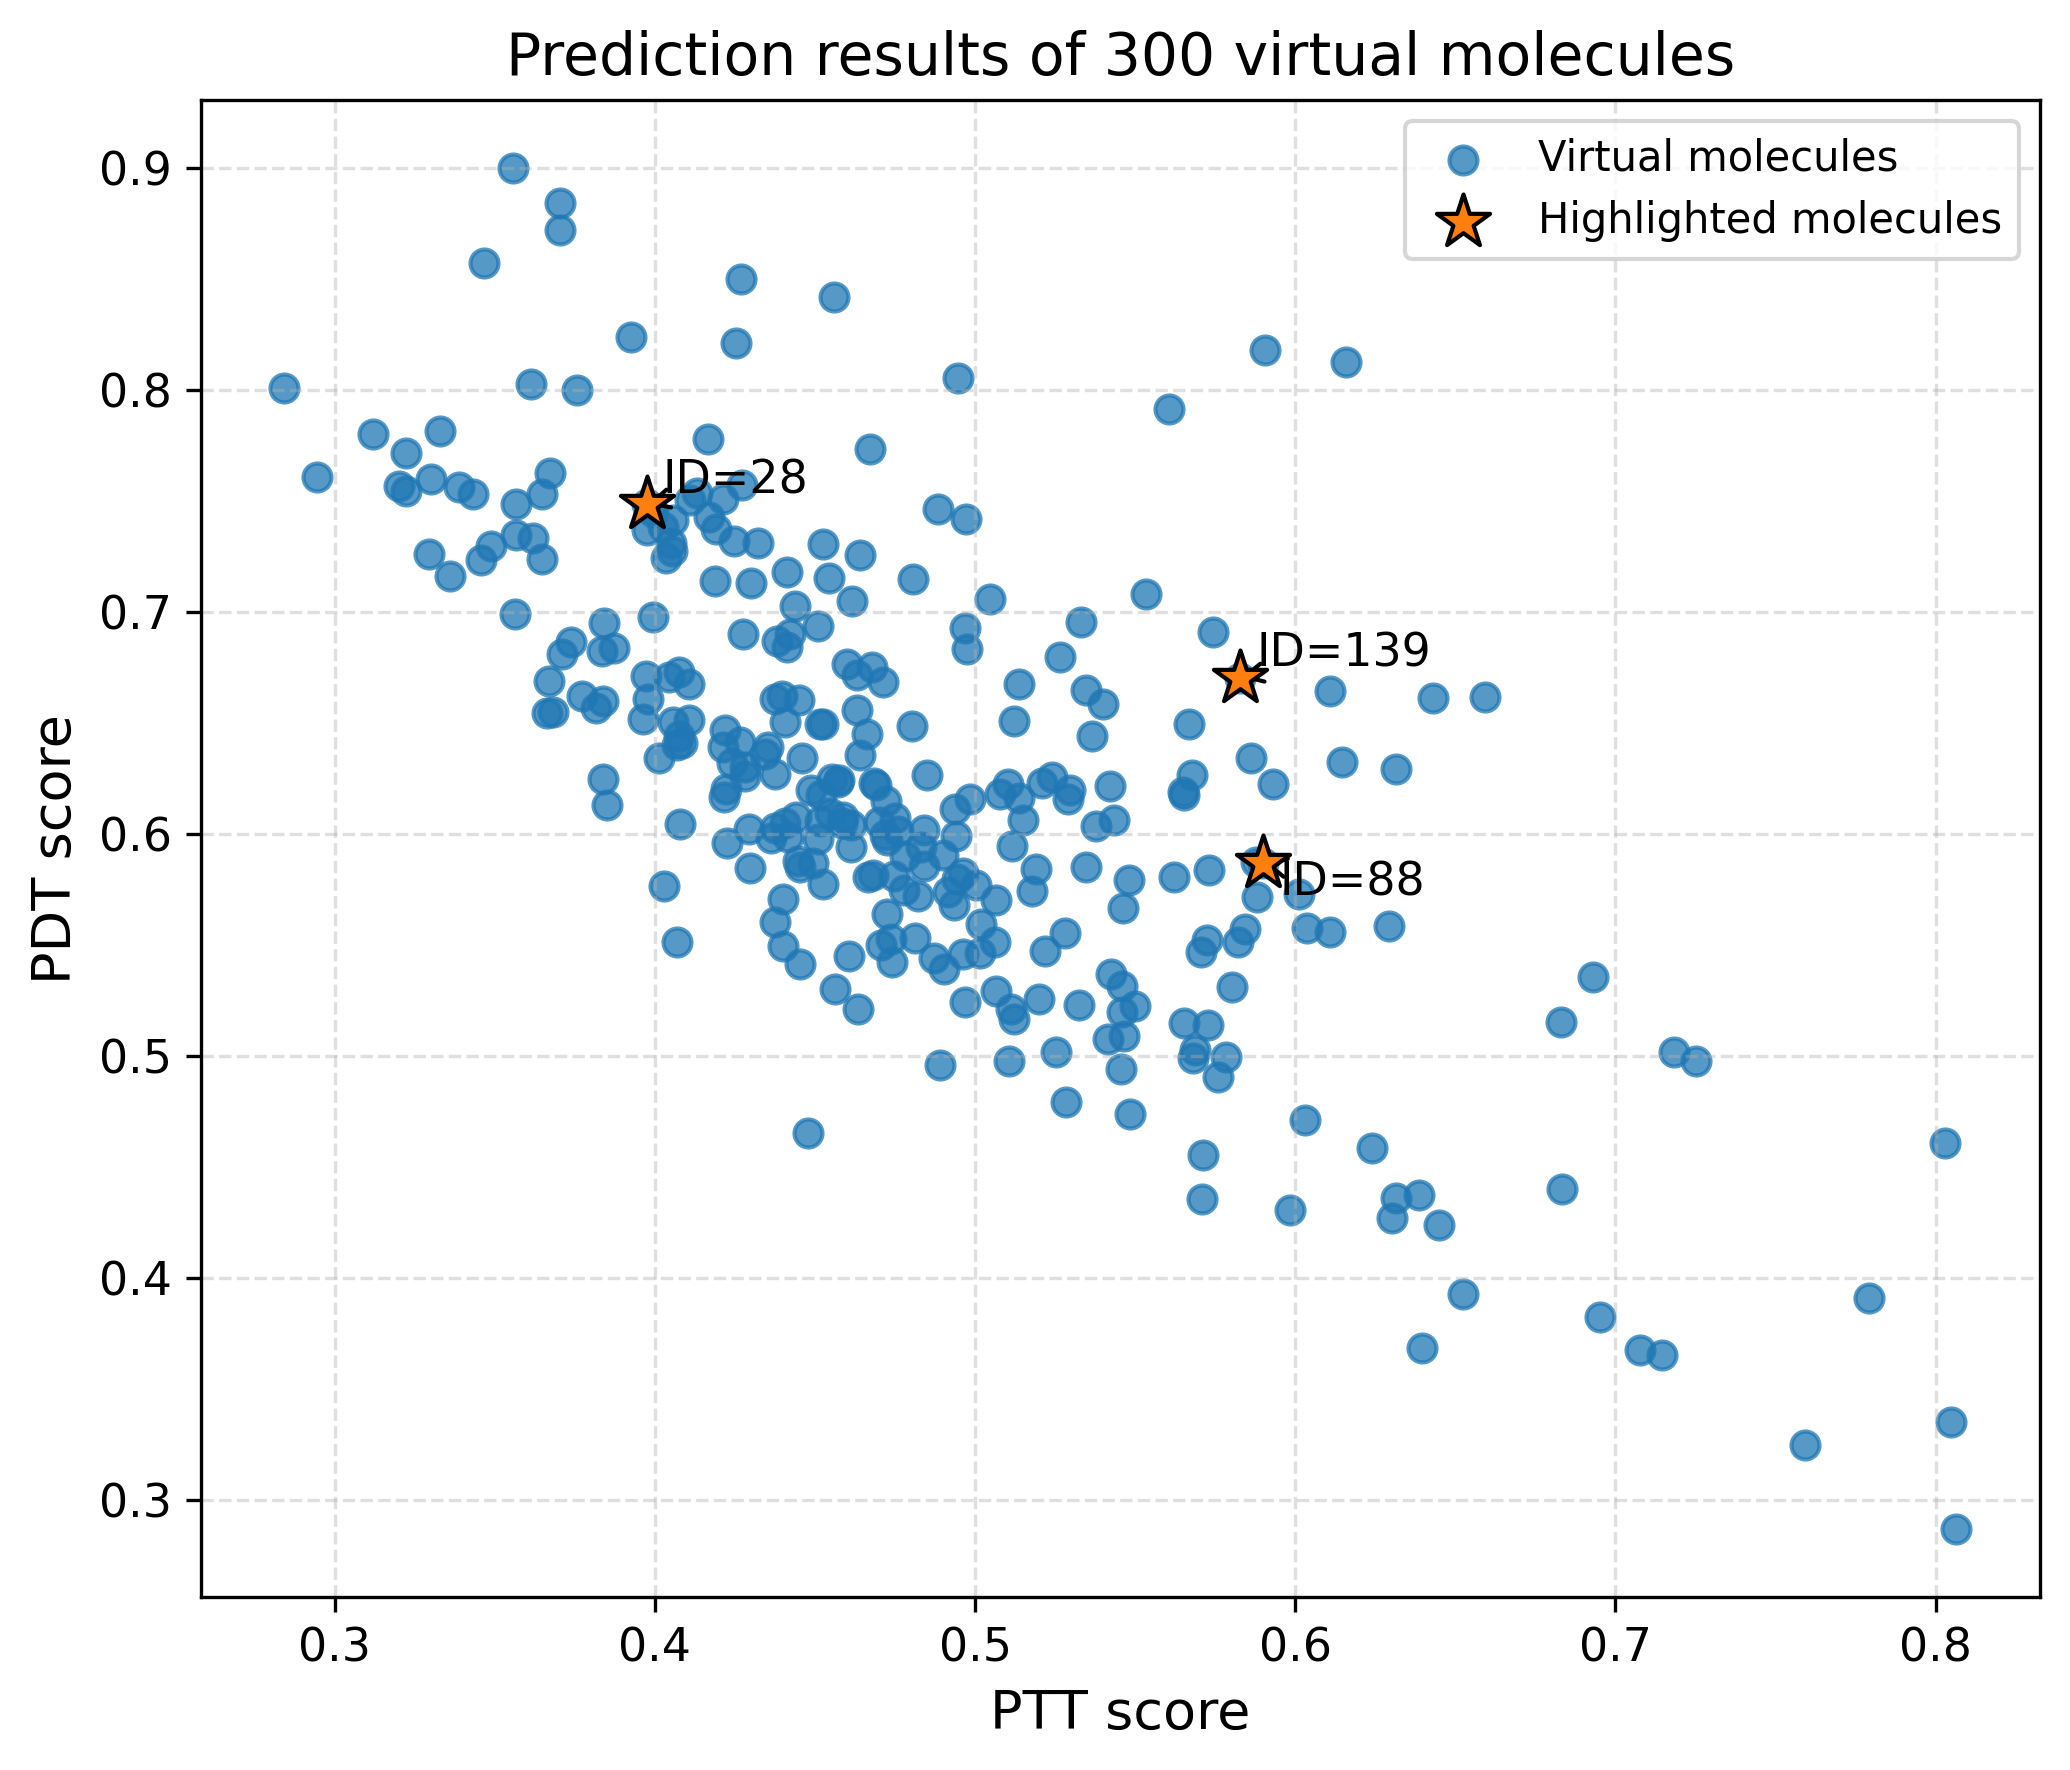

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================================
# 1. 准备绘图数据
# =========================================
plot_df = virtual_result.copy()

# 为了避免 ID 有时候是字符串、有时候是整数，这里统一转成字符串来筛选
plot_df["ID_str"] = plot_df["ID"].astype(str)

target_ids = ["28", "88", "139"]
#target_ids = ["139"]

target_df = plot_df[plot_df["ID_str"].isin(target_ids)].copy()

# =========================================
# 2. 作图
# =========================================
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

# 所有分子
ax.scatter(
    plot_df["PTT_score"],
    plot_df["PDT_score"],
    s=45,
    alpha=0.75,
    label="Virtual molecules"
)

# 高亮目标分子
ax.scatter(
    target_df["PTT_score"],
    target_df["PDT_score"],
    s=180,
    marker="*",
    edgecolors="black",
    linewidths=1.0,
    zorder=5,
    label="Highlighted molecules"
)

# =========================================
# 3. 给目标点加文字标注
# =========================================
# 可手动设置不同偏移，避免文字重叠
offset_dict = {
    "28": (0.005, 0.005),
    "88": (0.005, -0.015),
    "139": (0.005, 0.005),
}

for _, row in target_df.iterrows():
    id_str = str(row["ID"])
    dx, dy = offset_dict.get(id_str, (0.005, 0.005))
    
    ax.annotate(
        f"ID={id_str}",
        xy=(row["PTT_score"], row["PDT_score"]),
        xytext=(row["PTT_score"] + dx, row["PDT_score"] + dy),
        fontsize=11,
        arrowprops=dict(arrowstyle="->", lw=1)
    )

# =========================================
# 4. 美化图像
# =========================================
ax.set_xlabel("PTT score", fontsize=13)
ax.set_ylabel("PDT score", fontsize=13)
ax.set_title("Prediction results of 300 virtual molecules", fontsize=14)

ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize=10)
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import numpy as np

# =========================
# 1. 复制原始结果
# =========================
virtual_result_scale = virtual_result.copy()

# =========================
# 2. 确保 PTT_score / PDT_score 是数值型
# =========================
virtual_result_scale["PTT_score"] = pd.to_numeric(
    virtual_result_scale["PTT_score"], errors="coerce"
)

virtual_result_scale["PDT_score"] = pd.to_numeric(
    virtual_result_scale["PDT_score"], errors="coerce"
)

# =========================
# 3. 定义 Min-Max 归一化函数
# =========================
def minmax_scale_col(s):
    min_val = s.min()
    max_val = s.max()

    if pd.isna(min_val) or pd.isna(max_val):
        return pd.Series(np.nan, index=s.index)

    if max_val == min_val:
        return pd.Series(0.0, index=s.index)

    return (s - min_val) / (max_val - min_val)


# =========================
# 4. 对 PTT_score 和 PDT_score 分别归一化
# =========================
virtual_result_scale["PTT_score_scaled"] = minmax_scale_col(
    virtual_result_scale["PTT_score"]
)

virtual_result_scale["PDT_score_scaled"] = minmax_scale_col(
    virtual_result_scale["PDT_score"]
)

# =========================
# 5. 计算综合归一化得分
#    PTT scaled + PDT scaled
# =========================
virtual_result_scale["Total_scaled_score"] = (
    virtual_result_scale["PTT_score_scaled"] +
    virtual_result_scale["PDT_score_scaled"]
)

# 可选：如果你想让综合得分也保持在 [0, 1]
virtual_result_scale["Total_scaled_score_mean"] = (
    virtual_result_scale["Total_scaled_score"] / 2
)

# =========================
# 6. 计算综合归一化得分排名
#    分数越高，排名越靠前
# =========================
virtual_result_scale["Total_scaled_rank"] = (
    virtual_result_scale["Total_scaled_score"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# =========================
# 7. 按新的综合归一化排名排序
# =========================
virtual_result_scale = virtual_result_scale.sort_values(
    by="Total_scaled_rank",
    ascending=True
).reset_index(drop=True)

virtual_result_scale

,ID,SMILES_x,PTT_score,PDT_score,PTT_rank,PDT_rank,Total_score,Total_rank,PTT_score_scaled,PDT_score_scaled,Total_scaled_score,Total_scaled_score_mean,Total_scaled_rank
0,55,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,0.615930,0.812515,25,10,1.428445,1,0.635066,0.857168,1.492234,0.746117,1
1,57,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,0.590438,0.817938,34,9,1.408376,2,0.586251,0.866008,1.452259,0.726129,2
2,45,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,0.560525,0.791351,60,15,1.351876,3,0.528970,0.822663,1.351633,0.675816,3
3,107,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,0.659401,0.661962,14,98,1.321363,4,0.718311,0.611717,1.330028,0.665014,4
4,65,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,0.643139,0.661385,17,99,1.304523,5,0.687170,0.610775,1.297945,0.648972,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,176,N#C/C(C#N)=C1C2=C(C=CC=C2)/C(C3=C/1C=CC4=C3N=C...,0.385000,0.612948,262,163,0.997948,291,0.192849,0.531807,0.724656,0.362328,296
296,177,N#C/C(C#N)=C1C2=C(C=CC=C2)/C(C3=C/1C=CC4=C3N=C...,0.445294,0.541256,189,247,0.986550,295,0.308308,0.414925,0.723233,0.361617,297
297,212,N#C/C(C#N)=C1C2=C(C=CC=C2)/C(C3=C/1C=CC4=C3N=C...,0.402966,0.576673,250,213,0.979638,298,0.227253,0.472666,0.699918,0.349959,298
298,46,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,0.406813,0.551117,243,237,0.957930,299,0.234621,0.431002,0.665623,0.332811,299


In [10]:
virtual_result_scale[virtual_result_scale['ID']==28]

,ID,SMILES_x,PTT_score,PDT_score,PTT_rank,PDT_rank,Total_score,Total_rank,PTT_score_scaled,PDT_score_scaled,Total_scaled_score,Total_scaled_score_mean,Total_scaled_rank
97,28,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,0.397401,0.748515,257,34,1.145916,77,0.216596,0.752827,0.969422,0.484711,98


In [11]:
virtual_result_scale[virtual_result_scale['ID']==88]

,ID,SMILES_x,PTT_score,PDT_score,PTT_rank,PDT_rank,Total_score,Total_rank,PTT_score_scaled,PDT_score_scaled,Total_scaled_score,Total_scaled_score_mean,Total_scaled_rank
41,88,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,0.590027,0.587123,35,196,1.17715,50,0.585464,0.489704,1.075168,0.537584,42


In [12]:
virtual_result_scale[virtual_result_scale['ID']==139]

,ID,SMILES_x,PTT_score,PDT_score,PTT_rank,PDT_rank,Total_score,Total_rank,PTT_score_scaled,PDT_score_scaled,Total_scaled_score,Total_scaled_score_mean,Total_scaled_rank
12,139,N#C/C(C#N)=C1C2=C(/C(C3=C/1C=CC4=C3N=C5C6=C(C7...,0.582758,0.670427,40,89,1.253185,16,0.571545,0.625516,1.197061,0.59853,13


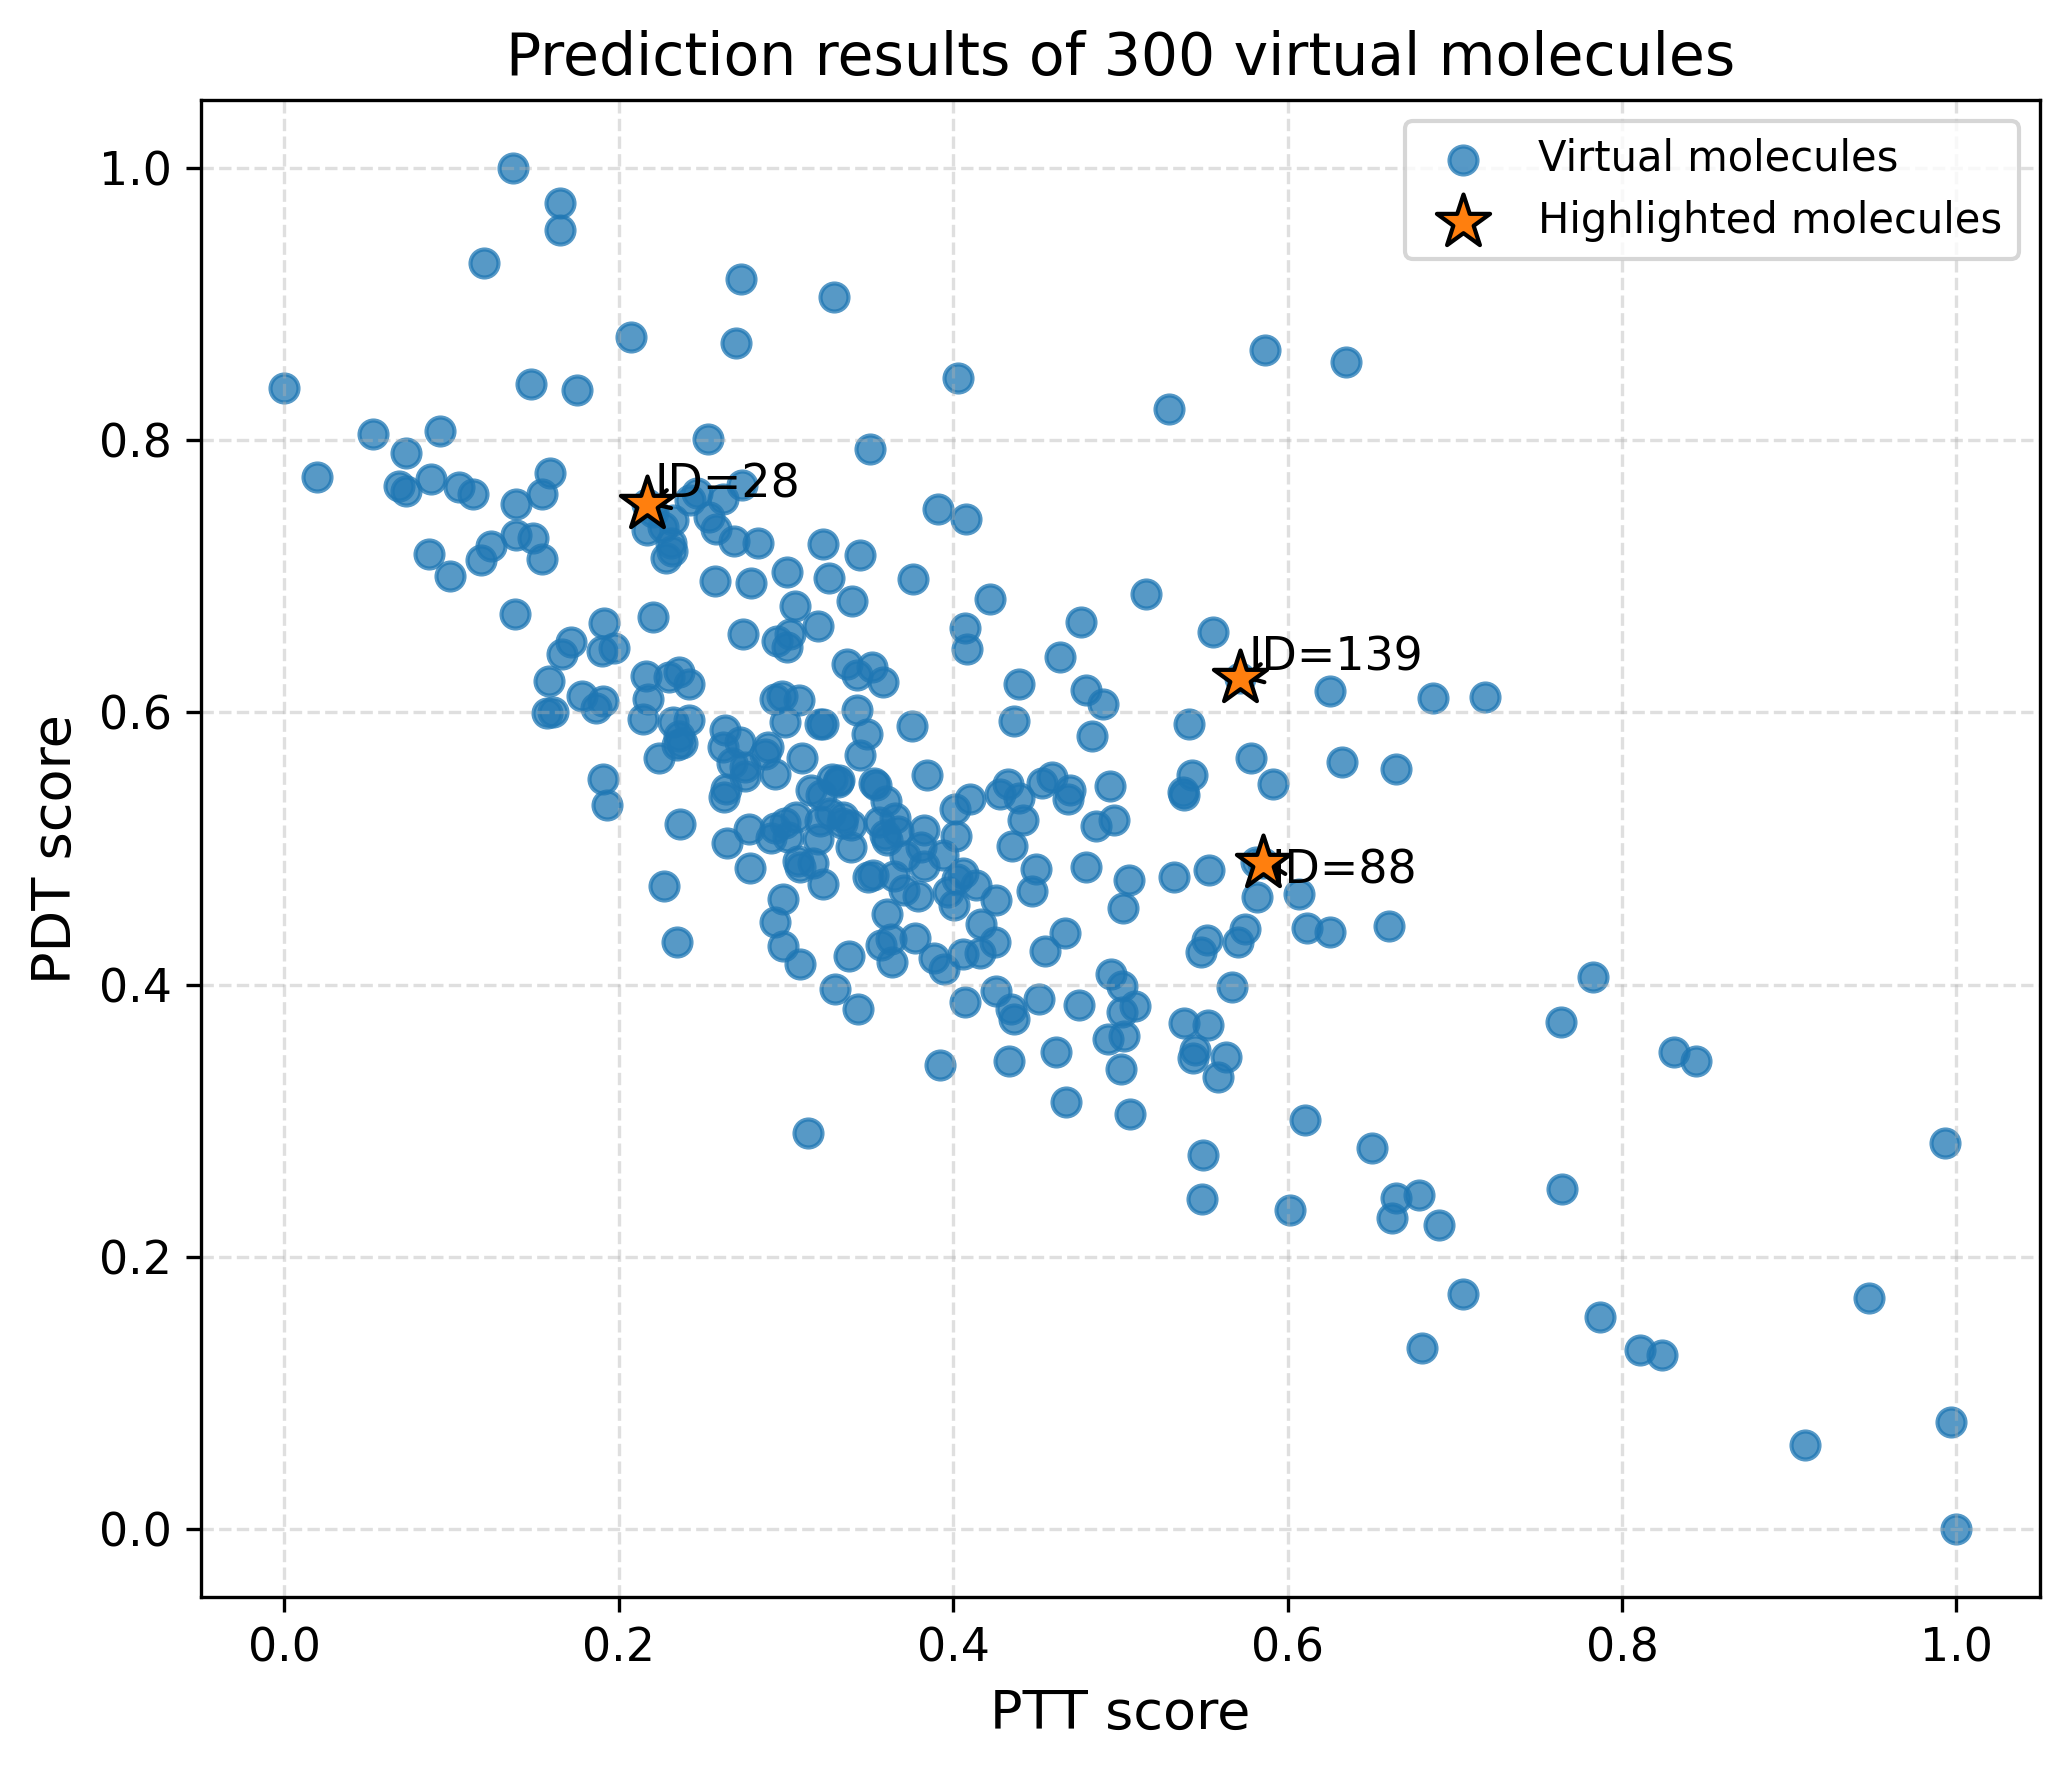

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================================
# 1. 准备绘图数据
# =========================================
plot_df = virtual_result_scale.copy()

# 为了避免 ID 有时候是字符串、有时候是整数，这里统一转成字符串来筛选
plot_df["ID_str"] = plot_df["ID"].astype(str)

target_ids = ["28", "88", "139"]
#target_ids = ["139"]

target_df = plot_df[plot_df["ID_str"].isin(target_ids)].copy()

# =========================================
# 2. 作图
# =========================================
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

# 所有分子
ax.scatter(
    plot_df["PTT_score_scaled"],
    plot_df["PDT_score_scaled"],
    s=45,
    alpha=0.75,
    label="Virtual molecules"
)

# 高亮目标分子
ax.scatter(
    target_df["PTT_score_scaled"],
    target_df["PDT_score_scaled"],
    s=180,
    marker="*",
    edgecolors="black",
    linewidths=1.0,
    zorder=5,
    label="Highlighted molecules"
)

# =========================================
# 3. 给目标点加文字标注
# =========================================
# 可手动设置不同偏移，避免文字重叠
offset_dict = {
    "28": (0.005, 0.005),
    "88": (0.005, -0.015),
    "139": (0.005, 0.005),
}

for _, row in target_df.iterrows():
    id_str = str(row["ID"])
    dx, dy = offset_dict.get(id_str, (0.005, 0.005))
    
    ax.annotate(
        f"ID={id_str}",
        xy=(row["PTT_score_scaled"], row["PDT_score_scaled"]),
        xytext=(row["PTT_score_scaled"] + dx, row["PDT_score_scaled"] + dy),
        fontsize=11,
        arrowprops=dict(arrowstyle="->", lw=1)
    )

# =========================================
# 4. 美化图像
# =========================================
ax.set_xlabel("PTT score", fontsize=13)
ax.set_ylabel("PDT score", fontsize=13)
ax.set_title("Prediction results of 300 virtual molecules", fontsize=14)

ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize=10)
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.show()